### Bitcoin Price Prediction using LogisticRegression, SVC, XGBClassifier in Sklearn.

##### 1. Importing Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. Loading Dataset

In [2]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/20-Bitcoin%20Price%20Prediction/bitcoin.csv

--2026-03-11 08:09:34--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/20-Bitcoin%20Price%20Prediction/bitcoin.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 221193 (216K) [text/plain]
Saving to: ‘bitcoin.csv’

bitcoin.csv         100%[===================>] 216.01K  --.-KB/s    in 0.06s   

2026-03-11 08:09:34 (3.61 MB/s) - ‘bitcoin.csv’ saved [221193/221193]



In [47]:
df = pd.read_csv('bitcoin.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


##### 3. Data Preprocessing

1. EDA

In [4]:
df.shape

(2713, 7)

In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555057,11323.914637,11323.914637,1.470462e+10
std,16106.428891,16537.390649,15608.572560,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399414,10762.644531,10202.387695,10462.259766,10462.259766,2.456992e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 148.5+ KB


In [31]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Year,0
Month,0
Day,0


2. Feature Engineering

In [48]:
splitted = df['Date'].str.split('-',expand = True)
df['Year'] = splitted[0].astype(int)
df['Month'] = splitted[1].astype(int)
df['Day'] = splitted[2].astype(int)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,2014,9,17
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,2014,9,18
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,2014,9,19
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,2014,9,20
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,2014,9,21


In [49]:
df['Date'] = pd.to_datetime(df['Date'])

In [28]:
df[df['Close'] == df['Adj Close']].shape, df.shape

((2713, 10), (2713, 10))

In [50]:
df.drop('Adj Close', axis=1, inplace=True)

In [51]:
df = df.rename(columns={'Volume': 'Price'})

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2713 non-null   datetime64[ns]
 1   Open    2713 non-null   float64       
 2   High    2713 non-null   float64       
 3   Low     2713 non-null   float64       
 4   Close   2713 non-null   float64       
 5   Price   2713 non-null   int64         
 6   Year    2713 non-null   int64         
 7   Month   2713 non-null   int64         
 8   Day     2713 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(4)
memory usage: 190.9 KB


In [52]:
# Build a binary target: 1 if next day's Close is higher, else 0
df_model = df.copy()
df_model['Target'] = (df_model['Close'].shift(-1) > df_model['Close']).astype(int)

# Drop last row (no next day available after shift)
df_model = df_model[:-1]

Feature = df_model.drop(['Date', 'Target'], axis=1)
X = Feature.values
y = df_model['Target'].values

3. Train Test Split

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. Standard Scalling

In [54]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##### 4. Build and the Fit the Models

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = [
    LogisticRegression(max_iter=2000),
    SVC(kernel='poly', probability=True),
    XGBClassifier(eval_metric='logloss', random_state=42)
 ]

for model in models:
    model.fit(X_train, y_train)

##### 5. Evaluate the Models

In [ ]:
from sklearn.metrics import roc_auc_score

for model in models:
    y_pred = model.predict(X_test)
    print(model.__class__.__name__)
    print(f"Receiver Operating Characteristic Auccuracy Score : {roc_auc_score(y_test, y_pred):.4f}")
    print('-' * 60)

LogisticRegression
Receiver Operating Characteristic Auccuracy Score : 0.5090
------------------------------------------------------------
SVC
Receiver Operating Characteristic Auccuracy Score : 0.5107
------------------------------------------------------------
XGBClassifier
Receiver Operating Characteristic Auccuracy Score : 0.5255
------------------------------------------------------------


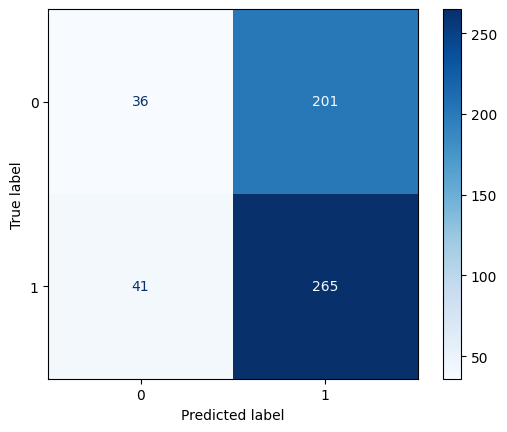

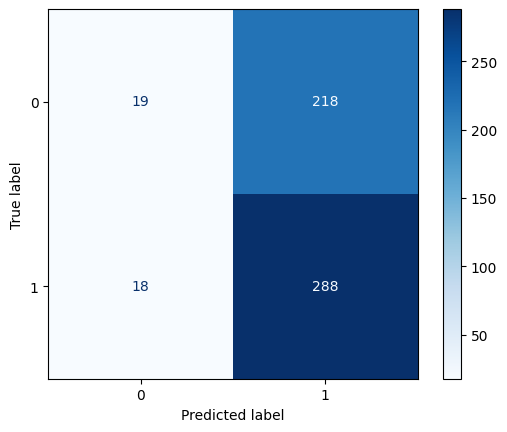

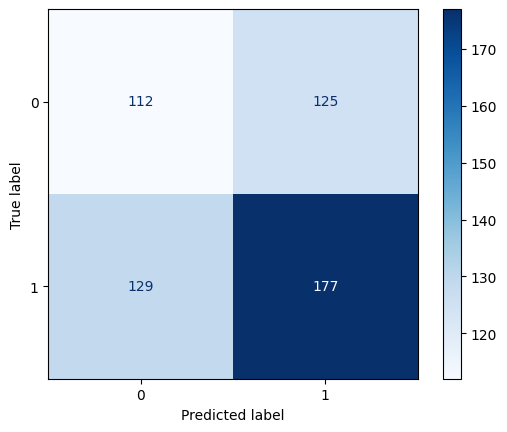

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

for i in range(len(models)):
    ConfusionMatrixDisplay.from_estimator(models[i], X_test, y_test, cmap='Blues')
plt.show()

##### 6. Make Prediction

In [64]:
for i in range(len(models)):
    y_pred = models[i].predict(X_test)
    print(f"{models[i].__class__.__name__} Predicted: {y_pred[0]},  Auctual: {y_test[0]}")

LogisticRegression Predicted: 1,  Auctual: 0
SVC Predicted: 1,  Auctual: 0
XGBClassifier Predicted: 0,  Auctual: 0


##### 7. GridSearch Cross Validation

In [65]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    },
    'SVC': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'poly'],
        'gamma': ['scale', 'auto']
    },
    'XGBClassifier': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }
}

estimators = {
    'LogisticRegression': LogisticRegression(max_iter=3000),
    'SVC': SVC(probability=True),
    'XGBClassifier': XGBClassifier(eval_metric='logloss', random_state=42)
}

best_models = {}
results = []

for name, estimator in estimators.items():
    print(f"Running GridSearchCV for {name}...")
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grids[name],
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    best_models[name] = grid.best_estimator_
    test_pred = best_models[name].predict(X_test)
    test_auc = roc_auc_score(y_test, test_pred)
    
    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Best CV ROC-AUC': round(grid.best_score_, 4),
        'Test ROC-AUC': round(test_auc, 4)
    })
    
    print(f"Best Params: {grid.best_params_}")
    print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")
    print(f"Test ROC-AUC: {test_auc:.4f}")
    print('-' * 60)

pd.DataFrame(results).sort_values(by='Best CV ROC-AUC', ascending=False)

Running GridSearchCV for LogisticRegression...
Best Params: {'C': 10, 'solver': 'liblinear'}
Best CV ROC-AUC: 0.5266
Test ROC-AUC: 0.5101
------------------------------------------------------------
Running GridSearchCV for SVC...
Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV ROC-AUC: 0.5316
Test ROC-AUC: 0.4870
------------------------------------------------------------
Running GridSearchCV for XGBClassifier...
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV ROC-AUC: 0.5096
Test ROC-AUC: 0.4889
------------------------------------------------------------


,Model,Best Params,Best CV ROC-AUC,Test ROC-AUC
1,SVC,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.5316,0.4870
0,LogisticRegression,"{'C': 10, 'solver': 'liblinear'}",0.5266,0.5101
2,XGBClassifier,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.5096,0.4889
